# Khám phá dữ liệu (EDA) — Spark SQL


## Setup & Imports

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("FraudDetection_Preprocessing") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/08 16:12:35 WARN Utils: Your hostname, MacBook-Air-cua-Bui-2.local, resolves to a loopback address: 127.0.0.1; using 172.20.10.5 instead (on interface en0)
26/04/08 16:12:35 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/08 16:12:36 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


---
## Tổng quan dữ liệu

### Load dữ liệu

In [2]:
train_df = spark.read.csv("data/fraudTrain.csv", header=True, inferSchema=True)
test_df = spark.read.csv("data/fraudTest.csv", header=True, inferSchema=True)

train_df = train_df.withColumn("trans_date_trans_time", F.to_timestamp("trans_date_trans_time", "yyyy-MM-dd HH:mm:ss")) \
                    .withColumn("dob", F.to_date("dob", "yyyy-MM-dd"))
test_df = test_df.withColumn("trans_date_trans_time", F.to_timestamp("trans_date_trans_time", "yyyy-MM-dd HH:mm:ss")) \
                  .withColumn("dob", F.to_date("dob", "yyyy-MM-dd"))

# Cache counts để tránh gọi .count() lặp lại nhiều lần
train_total = train_df.count()
test_total = test_df.count()

print(f"Train: {train_total:,} dòng, {len(train_df.columns)} cột")
print(f"Test:  {test_total:,} dòng, {len(test_df.columns)} cột")
print(f"Tổng:  {train_total + test_total:,} dòng")

Train: 1,296,675 dòng, 23 cột
Test:  555,719 dòng, 23 cột
Tổng:  1,852,394 dòng


### Schema và kiểu dữ liệu

In [3]:
print("=" * 60)
print("SCHEMA CỦA DATASET")
print("=" * 60)
train_df.printSchema()

SCHEMA CỦA DATASET
root
 |-- _c0: integer (nullable = true)
 |-- trans_date_trans_time: timestamp (nullable = true)
 |-- cc_num: long (nullable = true)
 |-- merchant: string (nullable = true)
 |-- category: string (nullable = true)
 |-- amt: double (nullable = true)
 |-- first: string (nullable = true)
 |-- last: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zip: integer (nullable = true)
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- city_pop: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- dob: date (nullable = true)
 |-- trans_num: string (nullable = true)
 |-- unix_time: integer (nullable = true)
 |-- merch_lat: double (nullable = true)
 |-- merch_long: double (nullable = true)
 |-- is_fraud: integer (nullable = true)



### Dữ liệu mẫu

In [4]:
train_df.show(5, truncate=False)

+---+---------------------+----------------+----------------------------------+-------------+------+---------+-------+------+----------------------------+--------------+-----+-----+-------+---------+--------+---------------------------------+----------+--------------------------------+----------+------------------+-----------+--------+
|_c0|trans_date_trans_time|cc_num          |merchant                          |category     |amt   |first    |last   |gender|street                      |city          |state|zip  |lat    |long     |city_pop|job                              |dob       |trans_num                       |unix_time |merch_lat         |merch_long |is_fraud|
+---+---------------------+----------------+----------------------------------+-------------+------+---------+-------+------+----------------------------+--------------+-----+-----+-------+---------+--------+---------------------------------+----------+--------------------------------+----------+------------------+--------

In [5]:
train_df.limit(10).toPandas()

,_c0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
5,5,2019-01-01 00:04:08,4767265376804500,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,40.3750,-75.2045,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
6,6,2019-01-01 00:04:42,30074693890476,fraud_Rowe-Vandervort,grocery_net,44.54,Kelsey,Richards,F,889 Sarah Station Suite 624,...,37.9931,-100.9893,2691,Arboriculturist,1993-08-16,83ec1cc84142af6e2acf10c44949e720,1325376282,37.162705,-100.153370,0
7,7,2019-01-01 00:05:08,6011360759745864,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,38.8432,-78.6003,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
8,8,2019-01-01 00:05:18,4922710831011201,fraud_Herzog Ltd,misc_pos,4.27,Heather,Chase,F,6888 Hicks Stream Suite 954,...,40.3359,-79.6607,1472,Public affairs consultant,1941-03-07,fc28024ce480f8ef21a32d64c93a29f5,1325376318,40.351813,-79.958146,0
9,9,2019-01-01 00:06:01,2720830304681674,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,36.5220,-87.3490,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0


### Ý nghĩa từng cột

| STT | Cột | Kiểu | Ý nghĩa |
|-----|-----|------|----------|
| 1 | `_c0` | int | Index (không cần thiết) |
| 2 | `trans_date_trans_time` | string | Ngày giờ giao dịch |
| 3 | `cc_num` | long | Số thẻ tín dụng |
| 4 | `merchant` | string | Tên merchant (cửa hàng) |
| 5 | `category` | string | Danh mục giao dịch |
| 6 | `amt` | double | Số tiền giao dịch (USD) |
| 7 | `first` | string | Tên khách hàng |
| 8 | `last` | string | Họ khách hàng |
| 9 | `gender` | string | Giới tính (M/F) |
| 10 | `street` | string | Địa chỉ đường |
| 11 | `city` | string | Thành phố |
| 12 | `state` | string | Bang/tiểu bang |
| 13 | `zip` | int | Mã bưu chính |
| 14 | `lat` | double | Vĩ độ khách hàng |
| 15 | `long` | double | Kinh độ khách hàng |
| 16 | `city_pop` | int | Dân số thành phố |
| 17 | `job` | string | Nghề nghiệp |
| 18 | `dob` | string | Ngày sinh |
| 19 | `trans_num` | string | Mã giao dịch (unique) |
| 20 | `unix_time` | int | Timestamp dạng Unix |
| 21 | `merch_lat` | double | Vĩ độ merchant |
| 22 | `merch_long` | double | Kinh độ merchant |
| 23 | `is_fraud` | int | **Nhãn: 0 = hợp lệ, 1 = gian lận** |

---
## Kiểm tra chất lượng dữ liệu

### Missing Values

In [6]:
train_df.createOrReplaceTempView("train")
test_df.createOrReplaceTempView("test")

print("=" * 60)
print("MISSING VALUES - TẬP TRAIN")
print("=" * 60)

null_counts = train_df.select(
    [F.sum(F.when(F.col(c).isNull() | F.isnan(c) if dict(train_df.dtypes)[c] in ('double', 'float') else F.col(c).isNull(), 1).otherwise(0)).alias(c) 
     for c in train_df.columns]
)
null_counts.toPandas().T.rename(columns={0: 'null_count'})

MISSING VALUES - TẬP TRAIN


,null_count
_c0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [7]:
print("=" * 60)
print("MISSING VALUES - TẬP TEST")
print("=" * 60)

null_counts_test = test_df.select(
    [F.sum(F.when(F.col(c).isNull() | F.isnan(c) if dict(test_df.dtypes)[c] in ('double', 'float') else F.col(c).isNull(), 1).otherwise(0)).alias(c) 
     for c in test_df.columns]
)
null_counts_test.toPandas().T.rename(columns={0: 'null_count'})

MISSING VALUES - TẬP TEST


,null_count
_c0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


### Duplicate Records

In [8]:
print("=" * 60)
print("KIỂM TRA DUPLICATE RECORDS")
print("=" * 60)

# Theo trans_num (định danh giao dịch — quan trọng nhất)
train_distinct = train_df.select("trans_num").distinct().count()
print(f"Train — Tổng dòng: {train_total:,}")
print(f"Train — trans_num distinct: {train_distinct:,}")
print(f"Train — Duplicate trans_num: {train_total - train_distinct:,}")
print()

test_distinct = test_df.select("trans_num").distinct().count()
print(f"Test — Tổng dòng: {test_total:,}")
print(f"Test — trans_num distinct: {test_distinct:,}")
print(f"Test — Duplicate trans_num: {test_total - test_distinct:,}")

KIỂM TRA DUPLICATE RECORDS


Train — Tổng dòng: 1,296,675
Train — trans_num distinct: 1,296,675
Train — Duplicate trans_num: 0

Test — Tổng dòng: 555,719
Test — trans_num distinct: 555,719
Test — Duplicate trans_num: 0


In [9]:
# Kiểm tra bổ sung: duplicate toàn bộ dòng (trừ index _c0)
cols_check = [c for c in train_df.columns if c != '_c0']
train_dup_full = train_total - train_df.select(cols_check).distinct().count()
test_dup_full = test_total - test_df.select(cols_check).distinct().count()

print(f"Train — Duplicate toàn bộ dòng (trừ _c0): {train_dup_full:,}")
print(f"Test  — Duplicate toàn bộ dòng (trừ _c0): {test_dup_full:,}")

Train — Duplicate toàn bộ dòng (trừ _c0): 0
Test  — Duplicate toàn bộ dòng (trừ _c0): 0


### Phát hiện Outlier (IQR)

In [10]:
print("=" * 60)
print("PHÁT HIỆN OUTLIER — CỘT AMOUNT (amt)")
print("=" * 60)

quantiles = train_df.approxQuantile("amt", [0.25, 0.5, 0.75], 0.01)
Q1, median, Q3 = quantiles[0], quantiles[1], quantiles[2]
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Median (50th percentile): ${median:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

outlier_count = train_df.filter((F.col("amt") < lower_bound) | (F.col("amt") > upper_bound)).count()
print(f"\nSố outlier (ngoài [{lower_bound:.2f}, {upper_bound:.2f}]): {outlier_count:,}")
print(f"Tỷ lệ outlier: {outlier_count / train_total * 100:.2f}%")

print("\nOutlier theo nhãn fraud:")
train_df.filter((F.col("amt") < lower_bound) | (F.col("amt") > upper_bound)) \
    .groupBy("is_fraud").count().show()

PHÁT HIỆN OUTLIER — CỘT AMOUNT (amt)


Q1 (25th percentile): $9.41
Median (50th percentile): $46.89
Q3 (75th percentile): $82.45
IQR: $73.04
Lower bound: $-100.15
Upper bound: $192.01

Số outlier (ngoài [-100.15, 192.01]): 68,416
Tỷ lệ outlier: 5.28%

Outlier theo nhãn fraud:
+--------+-----+
|is_fraud|count|
+--------+-----+
|       1| 5705|
|       0|62711|
+--------+-----+



**Nhận xét:**
- Dữ liệu **không có missing values** và **không có duplicate** (theo `trans_num` — định danh giao dịch) → dataset sạch.
- Outlier amount chiếm tỷ lệ đáng kể và **có tương quan với giao dịch fraud** — đây là thông tin hữu ích, không nên loại bỏ.
- Việc xử lý outlier (capping/winsorizing) sẽ được thực hiện ở **Bước 2 — Tiền xử lý**, không xử lý ngay trong EDA để tránh làm méo insight.

---
## Thống kê mô tả và kiểm tra phân bố dữ liệu

In [11]:
print("=" * 60)
print("THỐNG KÊ MÔ TẢ — CỘT AMOUNT")
print("=" * 60)

spark.sql("""
    SELECT 
        COUNT(amt) as count,
        ROUND(MIN(amt), 2) as min,
        ROUND(MAX(amt), 2) as max,
        ROUND(AVG(amt), 2) as mean,
        ROUND(STDDEV(amt), 2) as std,
        ROUND(PERCENTILE_APPROX(amt, 0.5), 2) as median
    FROM train
""").show(truncate=False)

THỐNG KÊ MÔ TẢ — CỘT AMOUNT
+-------+---+-------+-----+------+------+
|count  |min|max    |mean |std   |median|
+-------+---+-------+-----+------+------+
|1296675|1.0|28948.9|70.35|160.32|47.51 |
+-------+---+-------+-----+------+------+



In [12]:
print("=" * 60)
print("AMOUNT THEO FRAUD vs NON-FRAUD")
print("=" * 60)

spark.sql("""
    SELECT 
        is_fraud,
        COUNT(*) as count,
        ROUND(MIN(amt), 2) as min_amt,
        ROUND(MAX(amt), 2) as max_amt,
        ROUND(AVG(amt), 2) as mean_amt,
        ROUND(STDDEV(amt), 2) as std_amt,
        ROUND(PERCENTILE_APPROX(amt, 0.5), 2) as median_amt
    FROM train
    GROUP BY is_fraud
    ORDER BY is_fraud
""").show(truncate=False)

AMOUNT THEO FRAUD vs NON-FRAUD
+--------+-------+-------+-------+--------+-------+----------+
|is_fraud|count  |min_amt|max_amt|mean_amt|std_amt|median_amt|
+--------+-------+-------+-------+--------+-------+----------+
|0       |1289169|1.0    |28948.9|67.67   |154.01 |47.29     |
|1       |7506   |1.06   |1376.04|531.32  |390.56 |394.72    |
+--------+-------+-------+-------+--------+-------+----------+



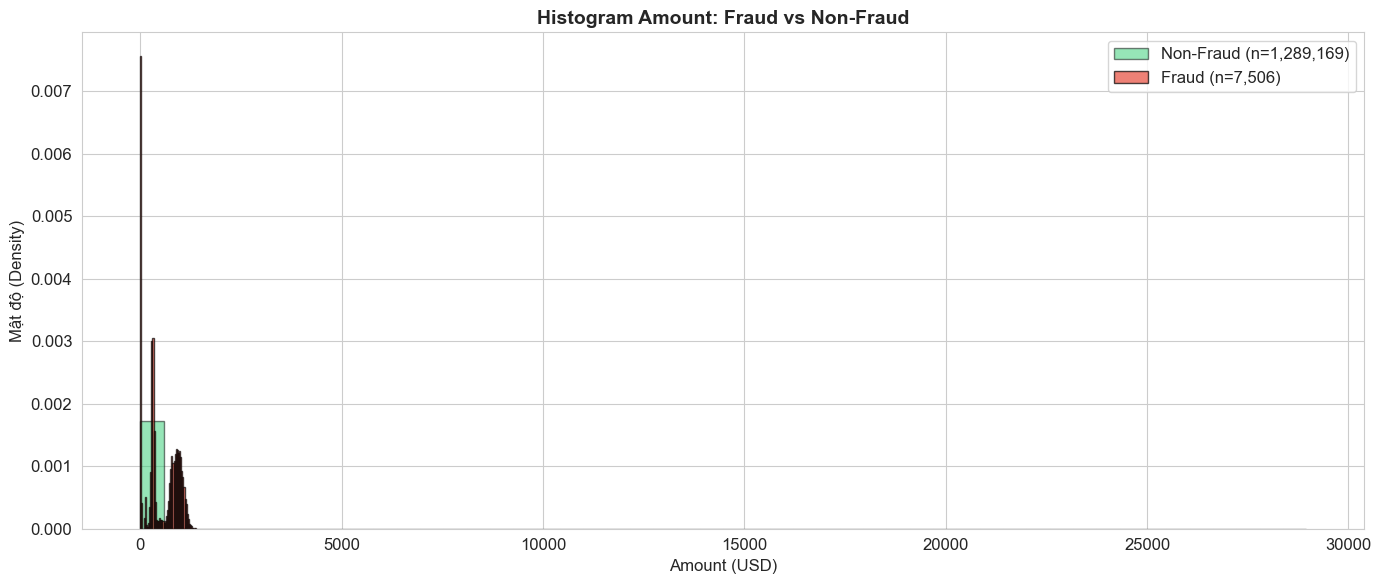

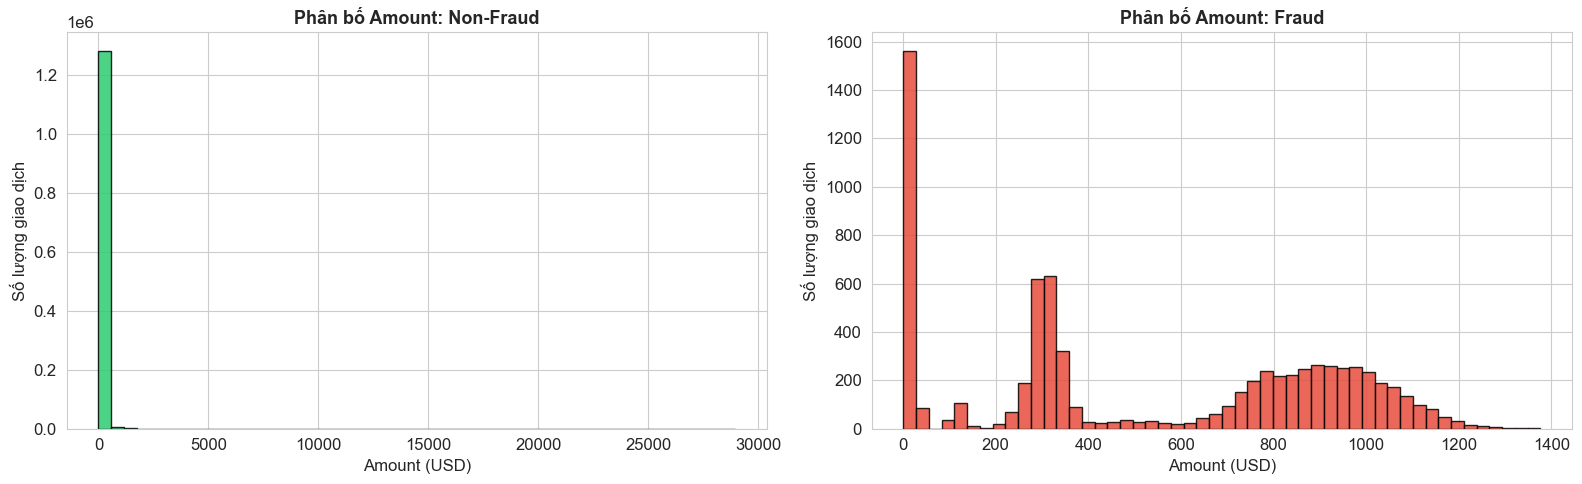

In [13]:
amt_pd = train_df.select('amt', 'is_fraud').toPandas()
amt_nonfraud = amt_pd[amt_pd['is_fraud'] == 0]['amt']
amt_fraud = amt_pd[amt_pd['is_fraud'] == 1]['amt']

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(amt_nonfraud, bins=50, alpha=0.5, label=f'Non-Fraud (n={len(amt_nonfraud):,})',
        color='#2ecc71', edgecolor='black', density=True)
ax.hist(amt_fraud, bins=50, alpha=0.7, label=f'Fraud (n={len(amt_fraud):,})',
        color='#e74c3c', edgecolor='black', density=True)
ax.set_xlabel('Amount (USD)', fontsize=12)
ax.set_ylabel('Mật độ (Density)', fontsize=12)
ax.set_title('Histogram Amount: Fraud vs Non-Fraud', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(amt_nonfraud, bins=50, color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Amount (USD)', fontsize=12)
axes[0].set_ylabel('Số lượng giao dịch', fontsize=12)
axes[0].set_title('Phân bố Amount: Non-Fraud', fontsize=13, fontweight='bold')

axes[1].hist(amt_fraud, bins=50, color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Amount (USD)', fontsize=12)
axes[1].set_ylabel('Số lượng giao dịch', fontsize=12)
axes[1].set_title('Phân bố Amount: Fraud', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

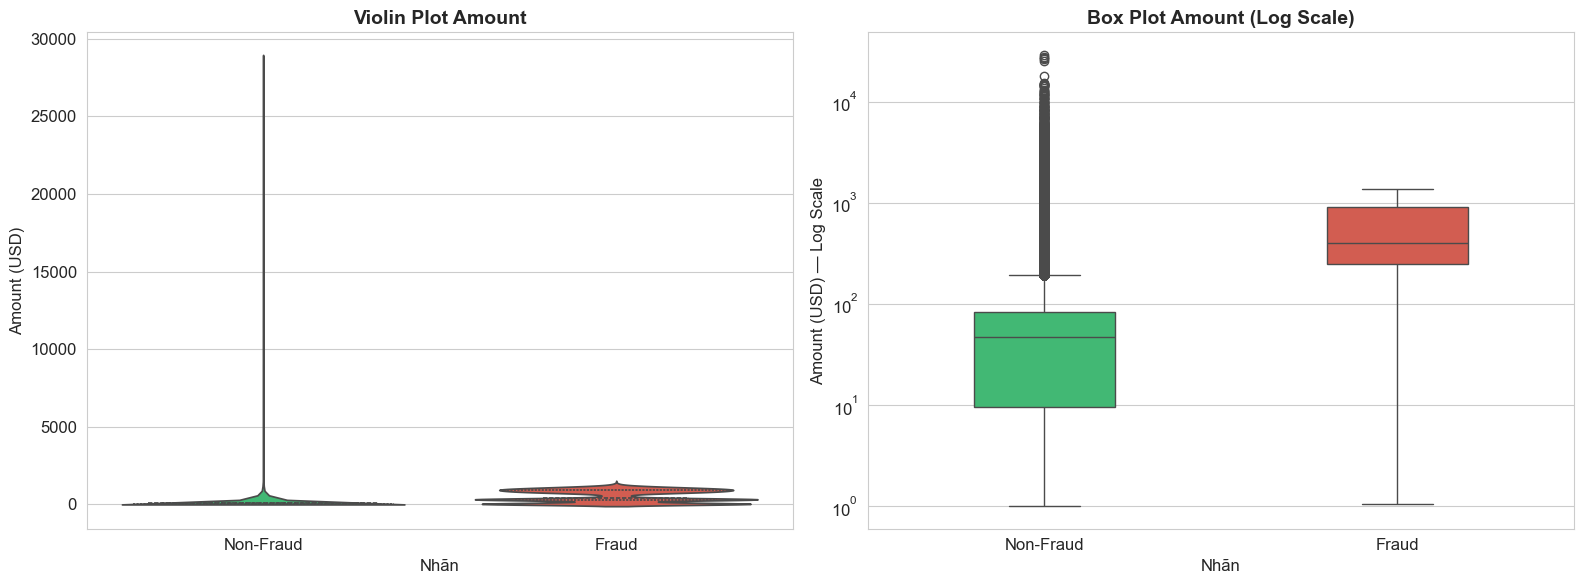

In [14]:
amt_data = train_df.select('amt', 'is_fraud').toPandas()
amt_data['label'] = amt_data['is_fraud'].map({0: 'Non-Fraud', 1: 'Fraud'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(x='label', y='amt', data=amt_data, ax=axes[0],
               palette={'Non-Fraud': '#2ecc71', 'Fraud': '#e74c3c'}, inner='quartile')
axes[0].set_xlabel('Nhãn', fontsize=12)
axes[0].set_ylabel('Amount (USD)', fontsize=12)
axes[0].set_title('Violin Plot Amount', fontsize=14, fontweight='bold')

sns.boxplot(x='label', y='amt', data=amt_data, ax=axes[1],
            palette={'Non-Fraud': '#2ecc71', 'Fraud': '#e74c3c'}, width=0.4)
axes[1].set_yscale('log')
axes[1].set_xlabel('Nhãn', fontsize=12)
axes[1].set_ylabel('Amount (USD) — Log Scale', fontsize=12)
axes[1].set_title('Box Plot Amount (Log Scale)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Giao dịch fraud có **amount trung bình cao hơn rõ rệt** so với non-fraud.
- Non-fraud tập trung ở mức amount thấp; fraud phân bố rộng hơn ở vùng amount cao.
- `amt` là một trong những **feature phân biệt mạnh nhất** giữa fraud và non-fraud.

### Kiểm tra phân bố (Skewness & Kurtosis)

Ngoài các thống kê mô tả cơ bản, cần kiểm tra phân bố của các biến số thông qua **Skewness** (độ lệch) và **Kurtosis** (độ nhọn) để xác định đặc điểm phân bố và chuẩn bị cho giai đoạn tiền xử lý.

In [15]:
print("=" * 60)
print("KIỂM TRA PHÂN BỐ DỮ LIỆU — SKEWNESS & KURTOSIS")
print("=" * 60)

numeric_cols = ['amt', 'lat', 'long', 'merch_lat', 'merch_long', 'city_pop']

skew_kurt_df = spark.sql(f"""
    SELECT
        {', '.join([f"ROUND(SKEWNESS({col}), 3) as {col}_skew" for col in numeric_cols])},
        {', '.join([f"ROUND(KURTOSIS({col}), 3) as {col}_kurt" for col in numeric_cols])}
    FROM train
""")

# Chuyển thành bảng dễ đọc
row = skew_kurt_df.collect()[0]
print(f"{'Biến':<15} {'Skewness':>12} {'Kurtosis':>12}  Nhận xét")
print("-" * 65)
for col in numeric_cols:
    skew = row[f'{col}_skew']
    kurt = row[f'{col}_kurt']
    if abs(skew) < 0.5:
        note = 'Gần đối xứng'
    elif abs(skew) < 1:
        note = 'Lệch vừa phải'
    elif skew > 0:
        note = 'Lệch phải mạnh'
    else:
        note = 'Lệch trái mạnh'
    print(f'{col:<15} {skew:>12} {kurt:>12}  {note}')

KIỂM TRA PHÂN BỐ DỮ LIỆU — SKEWNESS & KURTOSIS


Biến                Skewness     Kurtosis  Nhận xét
-----------------------------------------------------------------
amt                   42.278     4545.627  Lệch phải mạnh
lat                   -0.186        0.813  Gần đối xứng
long                   -1.15        1.856  Lệch trái mạnh
merch_lat             -0.182        0.796  Gần đối xứng
merch_long            -1.147        1.848  Lệch trái mạnh
city_pop               5.594       37.614  Lệch phải mạnh


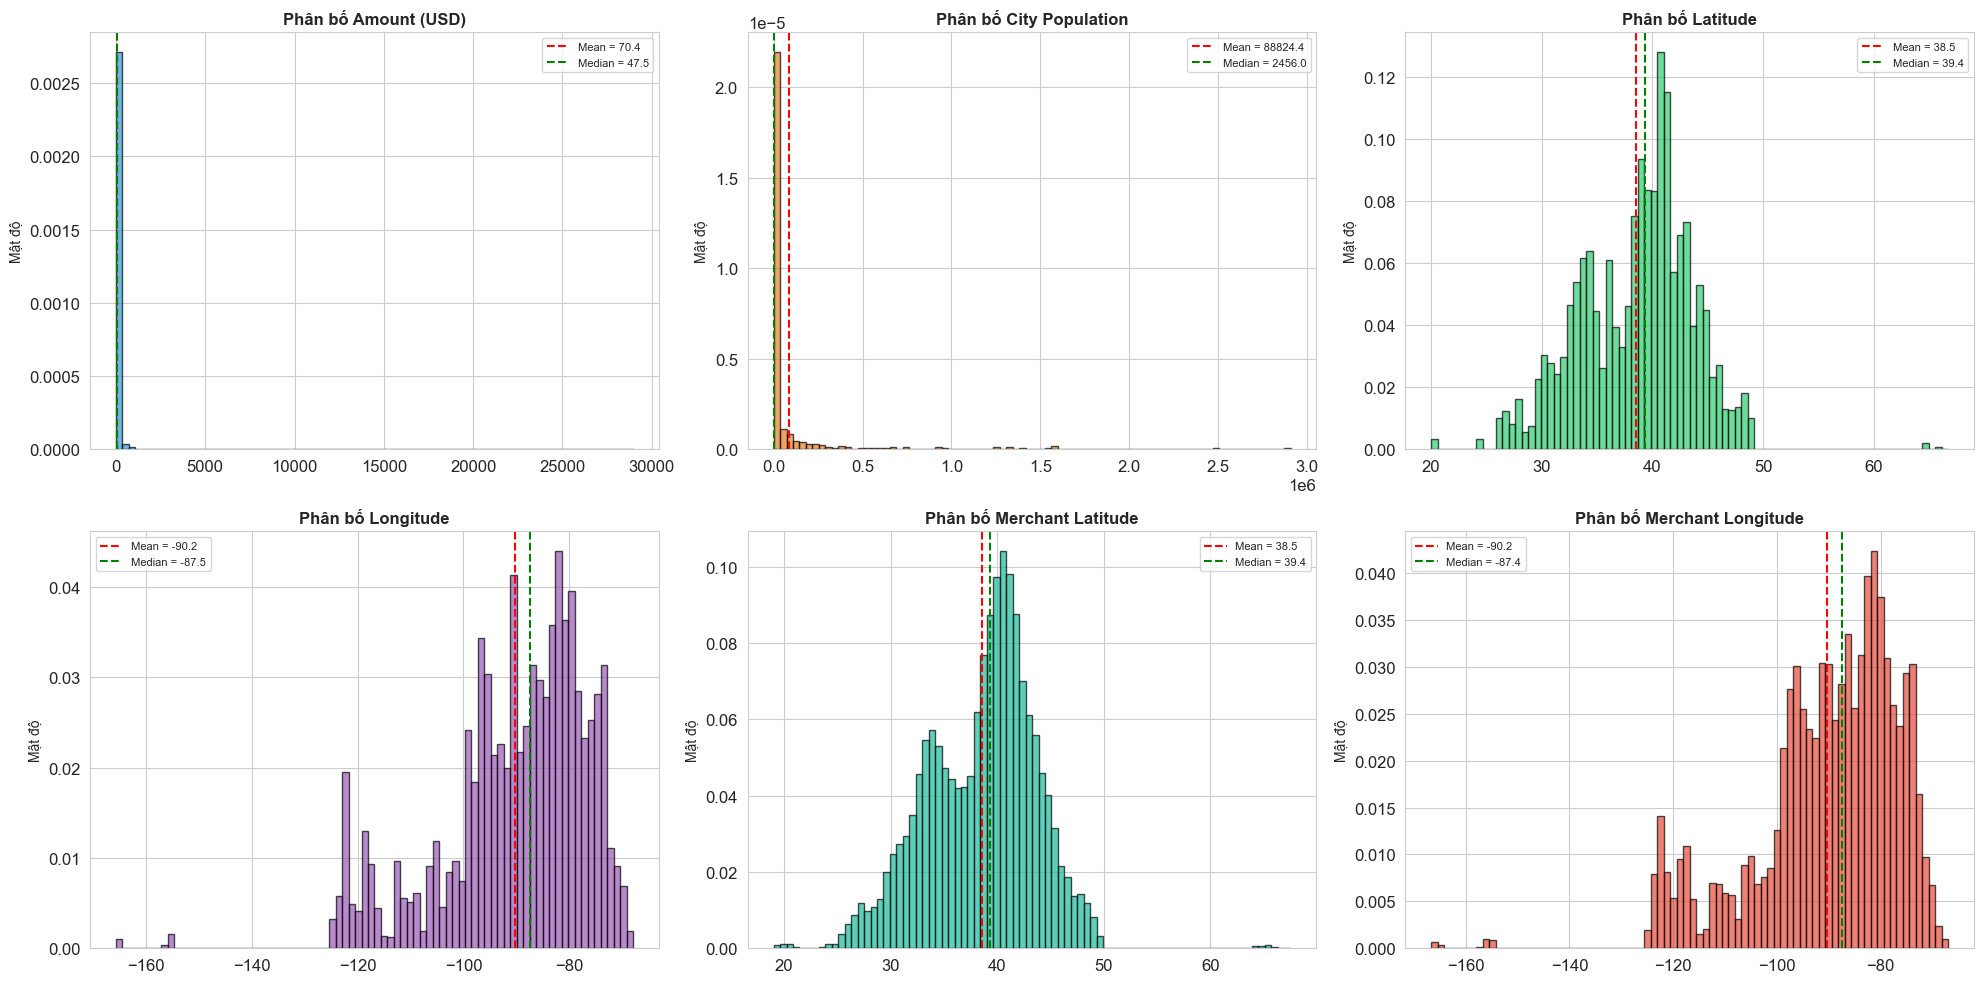

In [16]:

numeric_cols = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long']
titles = ['Amount (USD)', 'City Population', 'Latitude', 'Longitude', 
          'Merchant Latitude', 'Merchant Longitude']
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#1abc9c', '#e74c3c']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, (col, title, color) in enumerate(zip(numeric_cols, titles, colors)):
    data = train_df.select(col).toPandas()[col]
    axes[i].hist(data, bins=80, color=color, edgecolor='black', alpha=0.7, density=True)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {data.mean():.1f}')
    axes[i].axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label=f'Median = {data.median():.1f}')
    axes[i].set_title(f'Phân bố {title}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Mật độ', fontsize=10)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Biến `amt` **lệch phải rất mạnh** (skewness >> 1) — phần lớn giao dịch có giá trị nhỏ, một số ít có giá trị cực lớn. Mean (70,35) cao hơn nhiều so với Median (47,51) cũng xác nhận điều này.
- Biến `city_pop` cũng **lệch phải mạnh** — đa số khách hàng sống ở khu vực dân cư thấp.
- Các biến tọa độ (`lat`, `long`, `merch_lat`, `merch_long`) có phân bố **gần đối xứng**, skewness gần 0.
- Những đặc điểm này sẽ được lưu ý trong giai đoạn tiền xử lý dữ liệu, khi quyết định có cần áp dụng biến đổi (log transform, chuẩn hóa) hay không tùy thuộc vào loại mô hình được sử dụng.

---
## Phân tích đa chiều — Spark SQL

### Fraud theo Category

In [17]:
print("=" * 60)
print("FRAUD THEO CATEGORY")
print("=" * 60)

fraud_by_category = spark.sql("""
    SELECT 
        category,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY category
    ORDER BY fraud_rate_pct DESC
""")
fraud_by_category.show(20, truncate=False)

FRAUD THEO CATEGORY
+--------------+------------------+-----------+--------------+
|category      |total_transactions|fraud_count|fraud_rate_pct|
+--------------+------------------+-----------+--------------+
|shopping_net  |97543             |1713       |1.756         |
|misc_net      |63287             |915        |1.446         |
|grocery_pos   |123638            |1743       |1.410         |
|shopping_pos  |116672            |843        |0.723         |
|gas_transport |131659            |618        |0.469         |
|misc_pos      |79655             |250        |0.314         |
|grocery_net   |45452             |134        |0.295         |
|travel        |40507             |116        |0.286         |
|entertainment |94014             |233        |0.248         |
|personal_care |90758             |220        |0.242         |
|kids_pets     |113035            |239        |0.211         |
|food_dining   |91461             |151        |0.165         |
|home          |123115            |

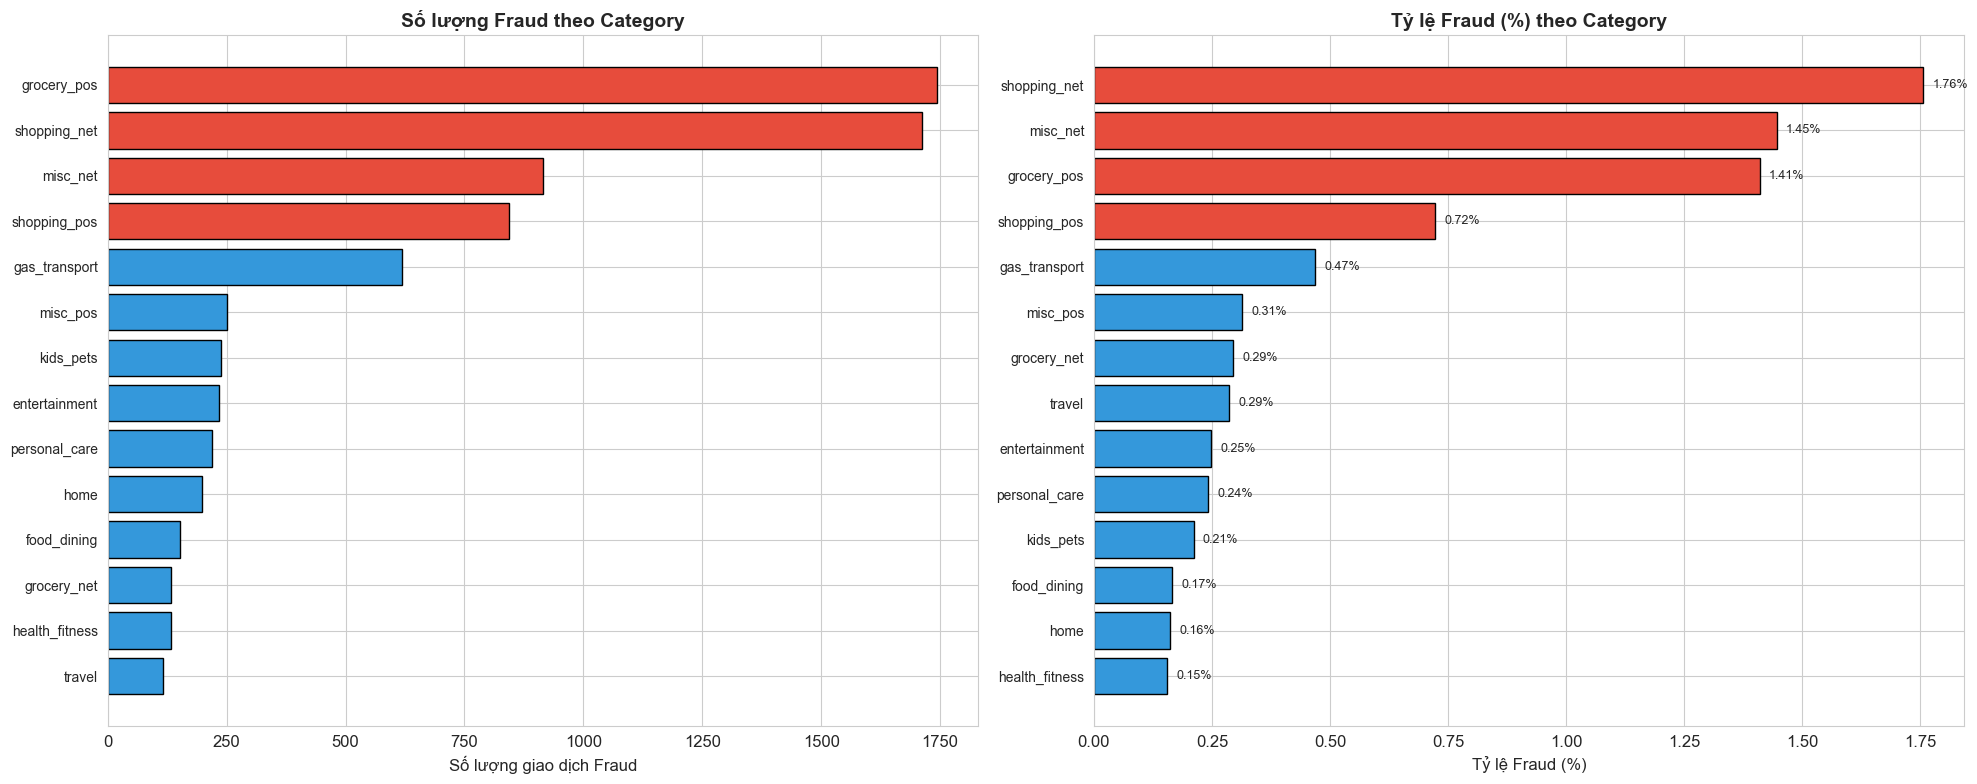

In [18]:
cat_pd = fraud_by_category.toPandas()
cat_pd['fraud_rate_pct'] = cat_pd['fraud_rate_pct'].astype(float)
cat_pd['fraud_count'] = cat_pd['fraud_count'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cat_sorted = cat_pd.sort_values('fraud_count', ascending=True)
mean_rate = cat_pd['fraud_rate_pct'].mean()
colors_bar = ['#e74c3c' if x > mean_rate else '#3498db' for x in cat_sorted['fraud_rate_pct']]
axes[0].barh(range(len(cat_sorted)), cat_sorted['fraud_count'].values, color=colors_bar, edgecolor='black')
axes[0].set_yticks(range(len(cat_sorted)))
axes[0].set_yticklabels(cat_sorted['category'].values, fontsize=10)
axes[0].set_xlabel('Số lượng giao dịch Fraud', fontsize=12)
axes[0].set_title('Số lượng Fraud theo Category', fontsize=14, fontweight='bold')

cat_sorted2 = cat_pd.sort_values('fraud_rate_pct', ascending=True)
colors_bar2 = ['#e74c3c' if x > mean_rate else '#3498db' for x in cat_sorted2['fraud_rate_pct']]
axes[1].barh(range(len(cat_sorted2)), cat_sorted2['fraud_rate_pct'].values, color=colors_bar2, edgecolor='black')
axes[1].set_yticks(range(len(cat_sorted2)))
axes[1].set_yticklabels(cat_sorted2['category'].values, fontsize=10)
axes[1].set_xlabel('Tỷ lệ Fraud (%)', fontsize=12)
axes[1].set_title('Tỷ lệ Fraud (%) theo Category', fontsize=14, fontweight='bold')

for i, val in enumerate(cat_sorted2['fraud_rate_pct'].values):
    axes[1].text(val + 0.02, i, f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Top 10 Merchant có nhiều Fraud nhất

In [19]:
print("=" * 60)
print("TOP 10 MERCHANT CÓ NHIỀU FRAUD NHẤT")
print("=" * 60)

top_merchant_fraud = spark.sql("""
    SELECT 
        merchant,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY merchant
    HAVING SUM(is_fraud) > 0
    ORDER BY fraud_count DESC
    LIMIT 10
""")
top_merchant_fraud.show(truncate=False)

TOP 10 MERCHANT CÓ NHIỀU FRAUD NHẤT
+---------------------+------------------+-----------+--------------+
|merchant             |total_transactions|fraud_count|fraud_rate_pct|
+---------------------+------------------+-----------+--------------+
|fraud_Rau and Sons   |2490              |49         |1.968         |
|fraud_Cormier LLC    |3649              |48         |1.315         |
|fraud_Kozey-Boehm    |1866              |48         |2.572         |
|fraud_Doyle Ltd      |2558              |47         |1.837         |
|fraud_Kilback LLC    |4403              |47         |1.067         |
|fraud_Vandervort-Funk|2474              |47         |1.900         |
|fraud_Kuhn LLC       |3510              |44         |1.254         |
|fraud_Padberg-Welch  |2424              |44         |1.815         |
|fraud_Terry-Huel     |1996              |43         |2.154         |
|fraud_Jast Ltd       |1953              |42         |2.151         |
+---------------------+------------------+-----------+

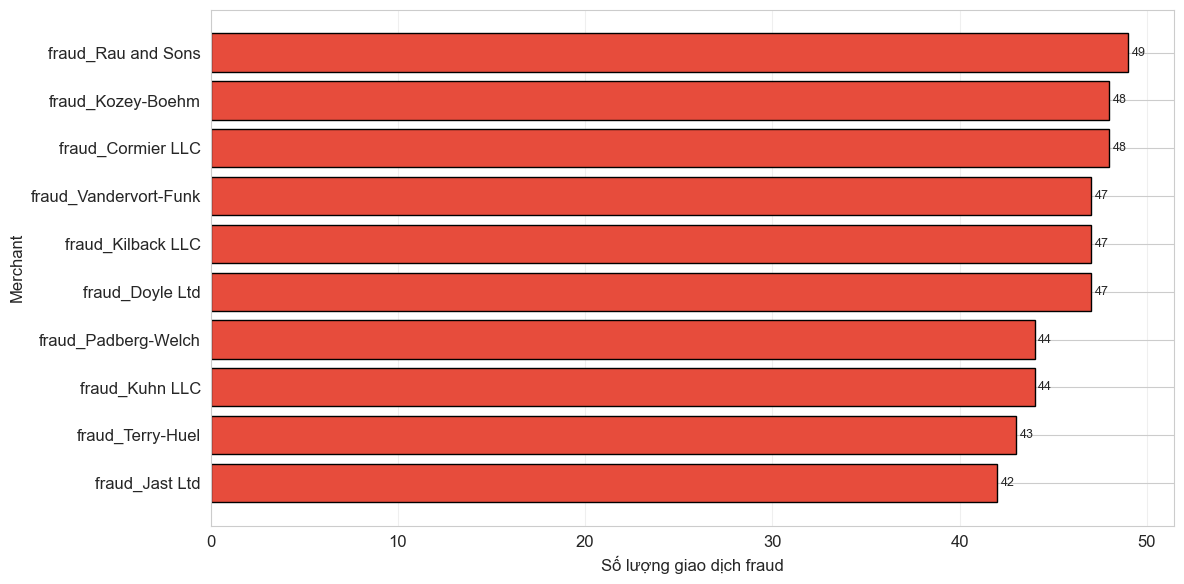

In [20]:

merchant_pd = top_merchant_fraud.toPandas().sort_values("fraud_count", ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.barh(merchant_pd["merchant"], merchant_pd["fraud_count"], color="#e74c3c", edgecolor="black")
plt.xlabel("Số lượng giao dịch fraud")
plt.ylabel("Merchant")
# plt.title("Top 10 Merchant có nhiều Fraud nhất")
plt.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, merchant_pd["fraud_count"]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, f"{int(val)}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### Fraud theo Giới tính

In [21]:
print("=" * 60)
print("FRAUD THEO GIỚI TÍNH")
print("=" * 60)

fraud_by_gender = spark.sql("""
    SELECT 
        gender,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY gender
    ORDER BY gender
""")
fraud_by_gender.show()

FRAUD THEO GIỚI TÍNH
+------+------------------+-----------+--------------+
|gender|total_transactions|fraud_count|fraud_rate_pct|
+------+------------------+-----------+--------------+
|     F|            709863|       3735|         0.526|
|     M|            586812|       3771|         0.643|
+------+------------------+-----------+--------------+



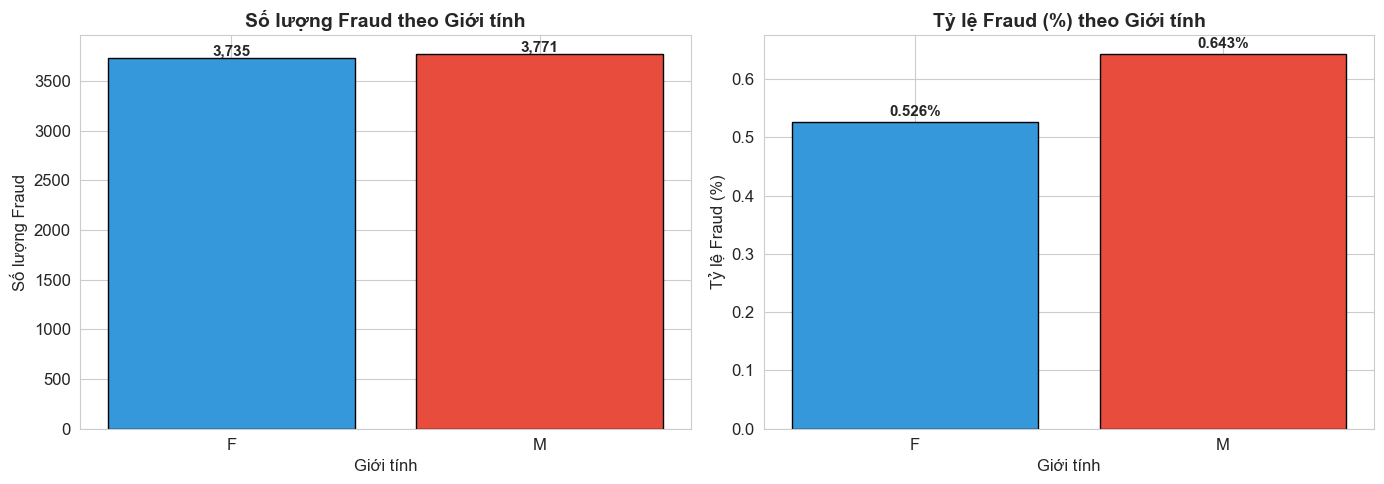

In [22]:
gender_pd = fraud_by_gender.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(gender_pd['gender'], gender_pd['fraud_count'], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_xlabel('Giới tính', fontsize=12)
axes[0].set_ylabel('Số lượng Fraud', fontsize=12)
axes[0].set_title('Số lượng Fraud theo Giới tính', fontsize=14, fontweight='bold')
for bar, val in zip(bars1, gender_pd['fraud_count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(gender_pd['gender'], gender_pd['fraud_rate_pct'], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_xlabel('Giới tính', fontsize=12)
axes[1].set_ylabel('Tỷ lệ Fraud (%)', fontsize=12)
axes[1].set_title('Tỷ lệ Fraud (%) theo Giới tính', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, gender_pd['fraud_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Fraud theo Độ tuổi

In [23]:
print("=" * 60)
print("FRAUD THEO ĐỘ TUỔI")
print("=" * 60)

fraud_by_age = spark.sql("""
    SELECT 
        CASE 
            WHEN age < 20 THEN '< 20'
            WHEN age BETWEEN 20 AND 29 THEN '20-29'
            WHEN age BETWEEN 30 AND 39 THEN '30-39'
            WHEN age BETWEEN 40 AND 49 THEN '40-49'
            WHEN age BETWEEN 50 AND 59 THEN '50-59'
            WHEN age BETWEEN 60 AND 69 THEN '60-69'
            WHEN age BETWEEN 70 AND 79 THEN '70-79'
            WHEN age >= 80 THEN '80+'
        END as age_group,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM (
        SELECT *, FLOOR(DATEDIFF(trans_date_trans_time, dob) / 365.25) as age
        FROM train
        WHERE dob IS NOT NULL AND trans_date_trans_time IS NOT NULL
    )
    WHERE age IS NOT NULL AND age >= 0 AND age <= 120
    GROUP BY age_group
    ORDER BY age_group
""")
fraud_by_age.show()

FRAUD THEO ĐỘ TUỔI


+---------+------------------+-----------+--------------+
|age_group|total_transactions|fraud_count|fraud_rate_pct|
+---------+------------------+-----------+--------------+
|    20-29|            209265|       1223|         0.584|
|    30-39|            291264|       1286|         0.442|
|    40-49|            304356|       1385|         0.455|
|    50-59|            184927|       1388|         0.751|
|    60-69|            136515|        855|         0.626|
|    70-79|             72863|        625|         0.858|
|      80+|             62644|        521|         0.832|
|     < 20|             34841|        223|         0.640|
+---------+------------------+-----------+--------------+



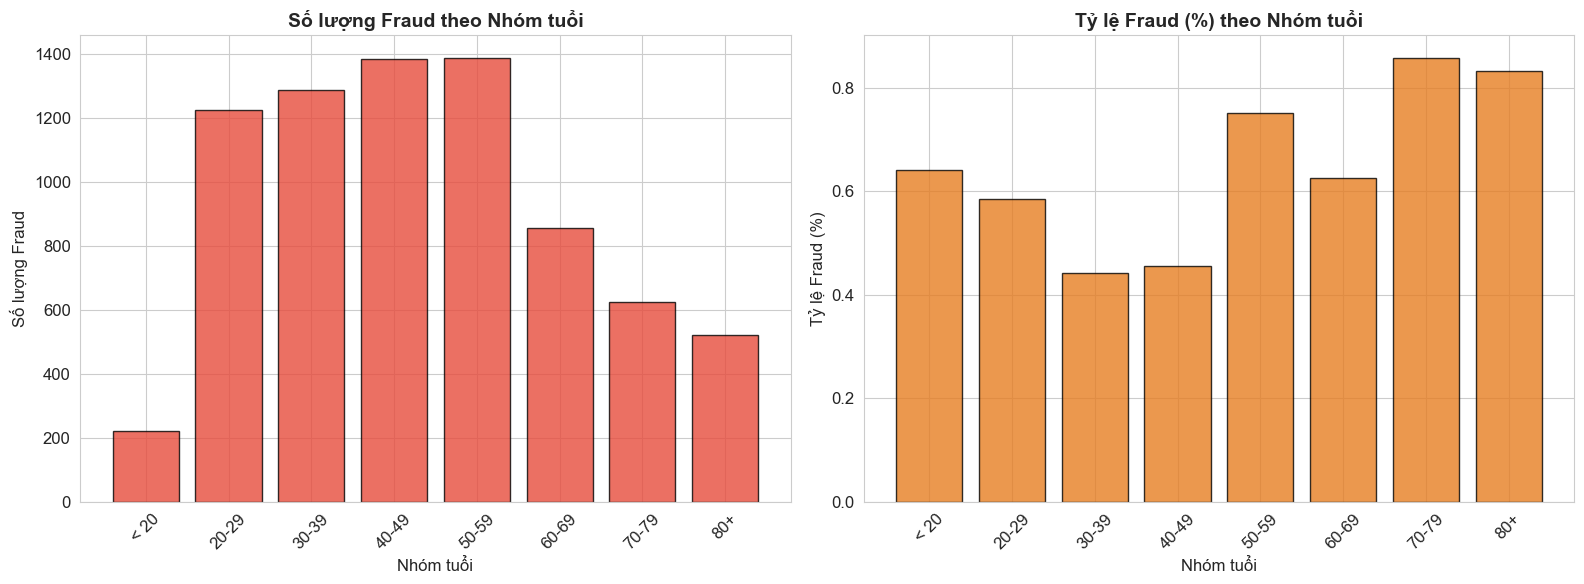

In [24]:
age_pd = fraud_by_age.toPandas()
age_order = ['< 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
age_pd['age_group'] = pd.Categorical(age_pd['age_group'], categories=age_order, ordered=True)
age_pd = age_pd.sort_values('age_group')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(age_pd['age_group'], age_pd['fraud_count'], color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Nhóm tuổi', fontsize=12)
axes[0].set_ylabel('Số lượng Fraud', fontsize=12)
axes[0].set_title('Số lượng Fraud theo Nhóm tuổi', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(age_pd['age_group'], age_pd['fraud_rate_pct'], color='#e67e22', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Nhóm tuổi', fontsize=12)
axes[1].set_ylabel('Tỷ lệ Fraud (%)', fontsize=12)
axes[1].set_title('Tỷ lệ Fraud (%) theo Nhóm tuổi', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Fraud theo Giờ trong ngày

In [25]:
print("=" * 60)
print("FRAUD THEO GIỜ TRONG NGÀY")
print("=" * 60)

fraud_by_hour = spark.sql("""
    SELECT 
        HOUR(trans_date_trans_time) as hour,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY HOUR(trans_date_trans_time)
    ORDER BY hour
""")
fraud_by_hour.show(24)

FRAUD THEO GIỜ TRONG NGÀY
+----+------------------+-----------+--------------+
|hour|total_transactions|fraud_count|fraud_rate_pct|
+----+------------------+-----------+--------------+
|   0|             42502|        635|         1.494|
|   1|             42869|        658|         1.535|
|   2|             42656|        625|         1.465|
|   3|             42769|        609|         1.424|
|   4|             41863|         46|         0.110|
|   5|             42171|         60|         0.142|
|   6|             42300|         40|         0.095|
|   7|             42203|         56|         0.133|
|   8|             42505|         49|         0.115|
|   9|             42185|         47|         0.111|
|  10|             42271|         40|         0.095|
|  11|             42082|         42|         0.100|
|  12|             65257|         67|         0.103|
|  13|             65314|         80|         0.122|
|  14|             64885|         86|         0.133|
|  15|             6

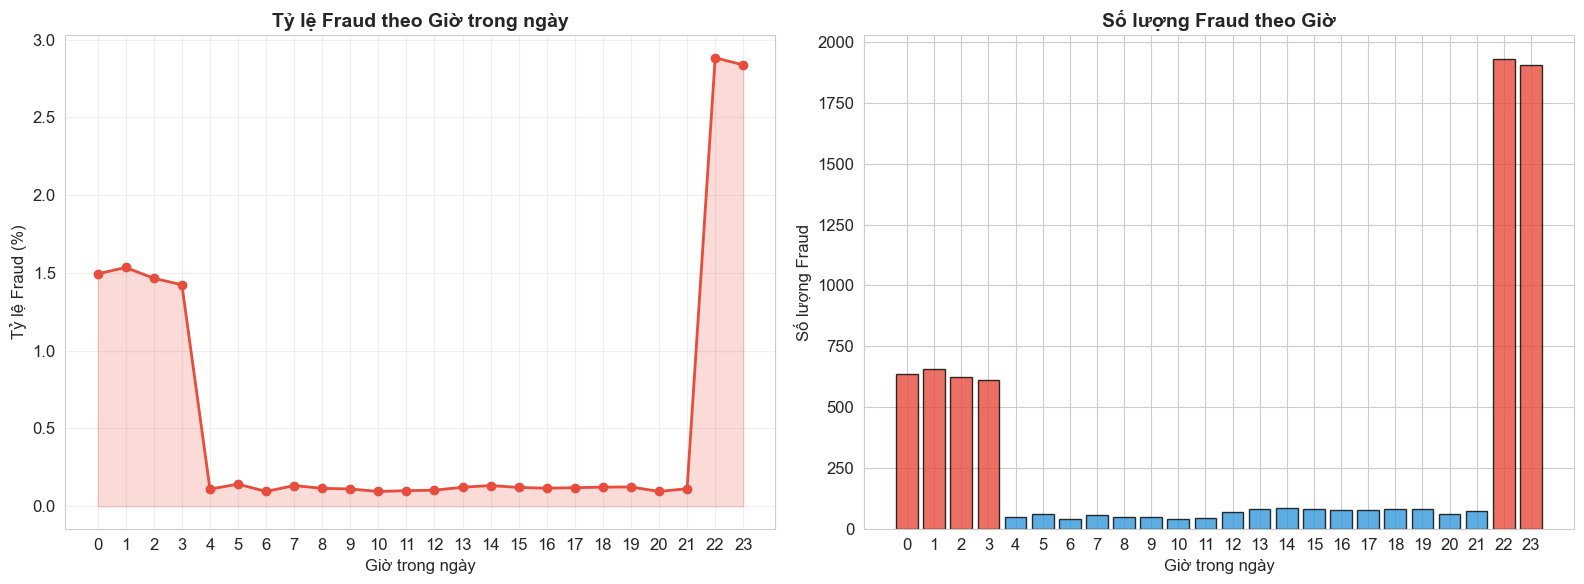

In [26]:
hour_pd = fraud_by_hour.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hour_pd['hour'], hour_pd['fraud_rate_pct'], 'o-', color='#e74c3c', linewidth=2, markersize=6)
axes[0].fill_between(hour_pd['hour'], hour_pd['fraud_rate_pct'], alpha=0.2, color='#e74c3c')
axes[0].set_xlabel('Giờ trong ngày', fontsize=12)
axes[0].set_ylabel('Tỷ lệ Fraud (%)', fontsize=12)
axes[0].set_title('Tỷ lệ Fraud theo Giờ trong ngày', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

colors_hour = ['#e74c3c' if x > hour_pd['fraud_rate_pct'].mean() else '#3498db' for x in hour_pd['fraud_rate_pct']]
axes[1].bar(hour_pd['hour'], hour_pd['fraud_count'], color=colors_hour, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Giờ trong ngày', fontsize=12)
axes[1].set_ylabel('Số lượng Fraud', fontsize=12)
axes[1].set_title('Số lượng Fraud theo Giờ', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

### Fraud theo Ngày trong tuần

In [27]:
print("=" * 60)
print("FRAUD THEO NGÀY TRONG TUẦN")
print("=" * 60)

fraud_by_dow = spark.sql("""
    SELECT 
        DAYOFWEEK(trans_date_trans_time) as day_num,
        CASE DAYOFWEEK(trans_date_trans_time)
            WHEN 1 THEN 'CN'
            WHEN 2 THEN 'T2'
            WHEN 3 THEN 'T3'
            WHEN 4 THEN 'T4'
            WHEN 5 THEN 'T5'
            WHEN 6 THEN 'T6'
            WHEN 7 THEN 'T7'
        END as day_of_week,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY DAYOFWEEK(trans_date_trans_time)
    ORDER BY day_num
""")
fraud_by_dow.show()

FRAUD THEO NGÀY TRONG TUẦN
+-------+-----------+------------------+-----------+--------------+
|day_num|day_of_week|total_transactions|fraud_count|fraud_rate_pct|
+-------+-----------+------------------+-----------+--------------+
|      1|         CN|            250579|       1216|         0.485|
|      2|         T2|            254282|       1182|         0.465|
|      3|         T3|            160227|        935|         0.584|
|      4|         T4|            131073|        859|         0.655|
|      5|         T5|            147285|       1008|         0.684|
|      6|         T6|            152272|       1079|         0.709|
|      7|         T7|            200957|       1227|         0.611|
+-------+-----------+------------------+-----------+--------------+



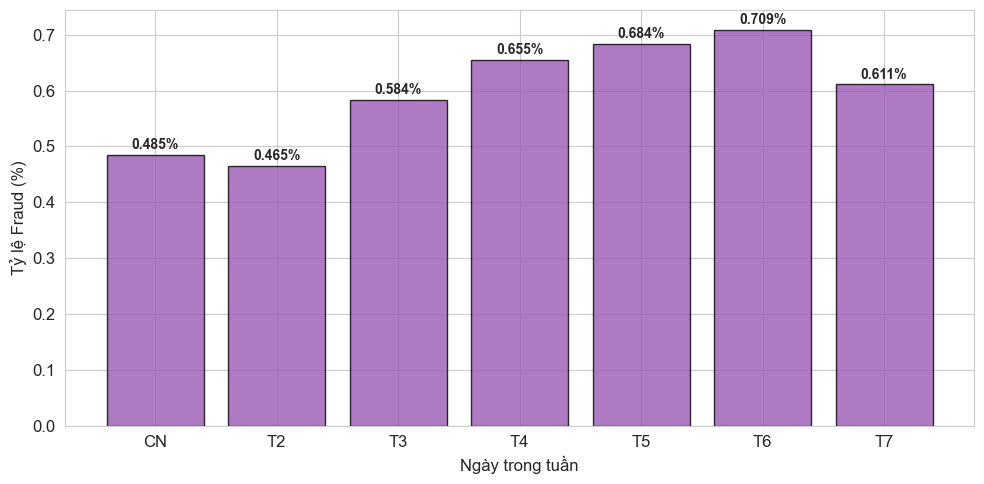

In [28]:
dow_pd = fraud_by_dow.toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow_pd['day_of_week'], dow_pd['fraud_rate_pct'], color='#9b59b6', edgecolor='black', alpha=0.8)
ax.set_xlabel('Ngày trong tuần', fontsize=12)
ax.set_ylabel('Tỷ lệ Fraud (%)', fontsize=12)
# ax.set_title('Tỷ lệ Fraud theo Ngày trong tuần', fontsize=14, fontweight='bold')
for bar, val in zip(bars, dow_pd['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### Fraud theo Tháng

In [29]:
print("=" * 60)
print("FRAUD THEO THÁNG")
print("=" * 60)

fraud_by_month = spark.sql("""
    SELECT 
        MONTH(trans_date_trans_time) as month,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY MONTH(trans_date_trans_time)
    ORDER BY month
""")
fraud_by_month.show(12)

FRAUD THEO THÁNG
+-----+------------------+-----------+--------------+
|month|total_transactions|fraud_count|fraud_rate_pct|
+-----+------------------+-----------+--------------+
|    1|            104727|        849|         0.811|
|    2|             97657|        853|         0.873|
|    3|            143789|        938|         0.652|
|    4|            134970|        678|         0.502|
|    5|            146875|        935|         0.637|
|    6|            143811|        688|         0.478|
|    7|             86596|        331|         0.382|
|    8|             87359|        382|         0.437|
|    9|             70652|        418|         0.592|
|   10|             68758|        454|         0.660|
|   11|             70421|        388|         0.551|
|   12|            141060|        592|         0.420|
+-----+------------------+-----------+--------------+



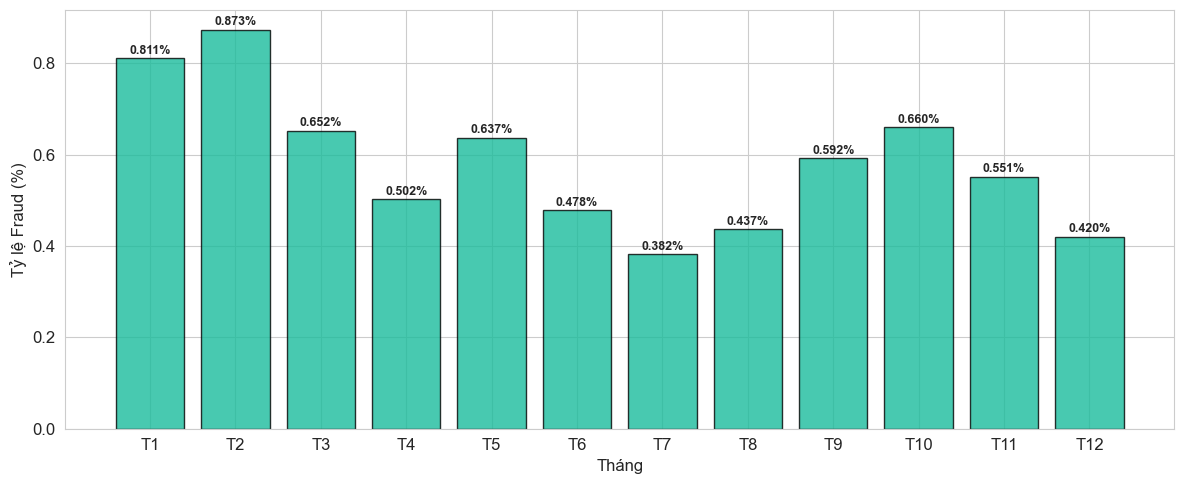

In [30]:
month_pd = fraud_by_month.toPandas()
month_names = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12']

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(month_pd))
bars = ax.bar(x, month_pd['fraud_rate_pct'], color='#1abc9c', edgecolor='black', alpha=0.8)
ax.set_xlabel('Tháng', fontsize=12)
ax.set_ylabel('Tỷ lệ Fraud (%)', fontsize=12)
# ax.set_title('Tỷ lệ Fraud theo Tháng', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(month_names[:len(month_pd)])
for bar, val in zip(bars, month_pd['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### Fraud theo State (Top 10, lọc ≥ 500 giao dịch)

In [31]:
print("=" * 60)
print("TOP 10 STATE CÓ TỶ LỆ FRAUD CAO NHẤT (≥ 500 giao dịch)")
print("=" * 60)

fraud_by_state = spark.sql("""
    SELECT 
        state,
        COUNT(*) as total_transactions,
        SUM(is_fraud) as fraud_count,
        ROUND(SUM(is_fraud) * 100.0 / COUNT(*), 3) as fraud_rate_pct
    FROM train
    GROUP BY state
    HAVING COUNT(*) >= 500
    ORDER BY fraud_rate_pct DESC
    LIMIT 10
""")
fraud_by_state.show(truncate=False)

TOP 10 STATE CÓ TỶ LỆ FRAUD CAO NHẤT (≥ 500 giao dịch)
+-----+------------------+-----------+--------------+
|state|total_transactions|fraud_count|fraud_rate_pct|
+-----+------------------+-----------+--------------+
|RI   |550               |15         |2.727         |
|AK   |2120              |36         |1.698         |
|NV   |5607              |47         |0.838         |
|CO   |13880             |113        |0.814         |
|OR   |18597             |149        |0.801         |
|TN   |17554             |140        |0.798         |
|NE   |24168             |180        |0.745         |
|ME   |16505             |119        |0.721         |
|NH   |8278              |59         |0.713         |
|OH   |46480             |321        |0.691         |
+-----+------------------+-----------+--------------+



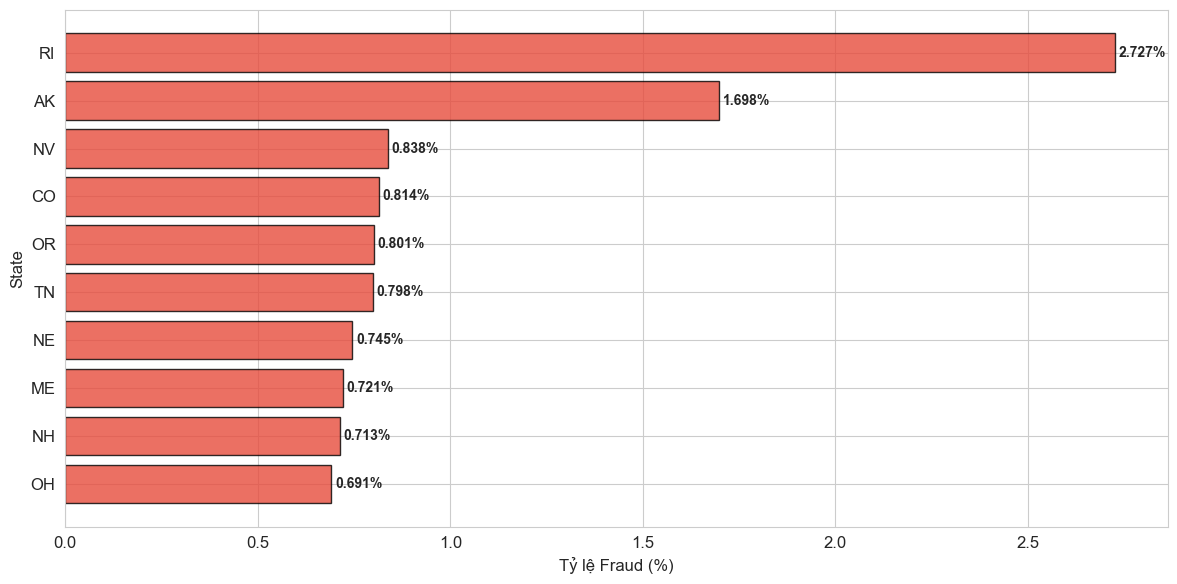

In [ ]:
state_pd = fraud_by_state.toPandas().sort_values('fraud_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(state_pd['state'], state_pd['fraud_rate_pct'], color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_xlabel('Tỷ lệ Fraud (%)', fontsize=12)
ax.set_ylabel('State', fontsize=12)
for bar, val in zip(bars, state_pd['fraud_rate_pct']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}%', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:**
- **Category:** Một số danh mục có tỷ lệ fraud cao hơn hẳn (shopping_net, grocery_pos...) — feature hữu ích.
- **Merchant:** Fraud phân bố khá đều, không tập trung ở một merchant cụ thể.
- **Gender:** Tỷ lệ fraud gần tương đương giữa M và F — gender ít ảnh hưởng.
- **Tuổi:** Người lớn tuổi (70+) có tỷ lệ bị fraud cao hơn.
- **Giờ:** Fraud tập trung vào **ban đêm (22h–3h)** — insight quan trọng nhất.
- **Ngày/Tháng:** Không có sự khác biệt đáng kể.
- **State:** Sau khi lọc các bang có ≥ 500 giao dịch, sự chênh lệch fraud rate giữa các bang không quá lớn — state có thể là feature phụ trợ.

---
## Phân tích khoảng cách Customer — Merchant

In [33]:
print("=" * 60)
print("PHÂN TÍCH KHOẢNG CÁCH CUSTOMER ↔ MERCHANT")
print("=" * 60)

train_with_dist = spark.sql("""
    SELECT *,
        6371 * 2 * ASIN(SQRT(
            POWER(SIN(RADIANS(merch_lat - lat) / 2), 2) +
            COS(RADIANS(lat)) * COS(RADIANS(merch_lat)) *
            POWER(SIN(RADIANS(merch_long - `long`) / 2), 2)
        )) as distance_km
    FROM train
""")

train_with_dist.createOrReplaceTempView("train_dist")

spark.sql("""
    SELECT 
        is_fraud,
        COUNT(*) as count,
        ROUND(AVG(distance_km), 3) as avg_distance_km,
        ROUND(MIN(distance_km), 3) as min_distance_km,
        ROUND(MAX(distance_km), 3) as max_distance_km,
        ROUND(PERCENTILE_APPROX(distance_km, 0.5), 3) as median_distance_km
    FROM train_dist
    GROUP BY is_fraud
    ORDER BY is_fraud
""").show(truncate=False)

PHÂN TÍCH KHOẢNG CÁCH CUSTOMER ↔ MERCHANT


+--------+-------+---------------+---------------+---------------+------------------+
|is_fraud|count  |avg_distance_km|min_distance_km|max_distance_km|median_distance_km|
+--------+-------+---------------+---------------+---------------+------------------+
|0       |1289169|76.114         |0.022          |152.117        |78.231            |
|1       |7506   |76.268         |0.739          |144.522        |77.917            |
+--------+-------+---------------+---------------+---------------+------------------+



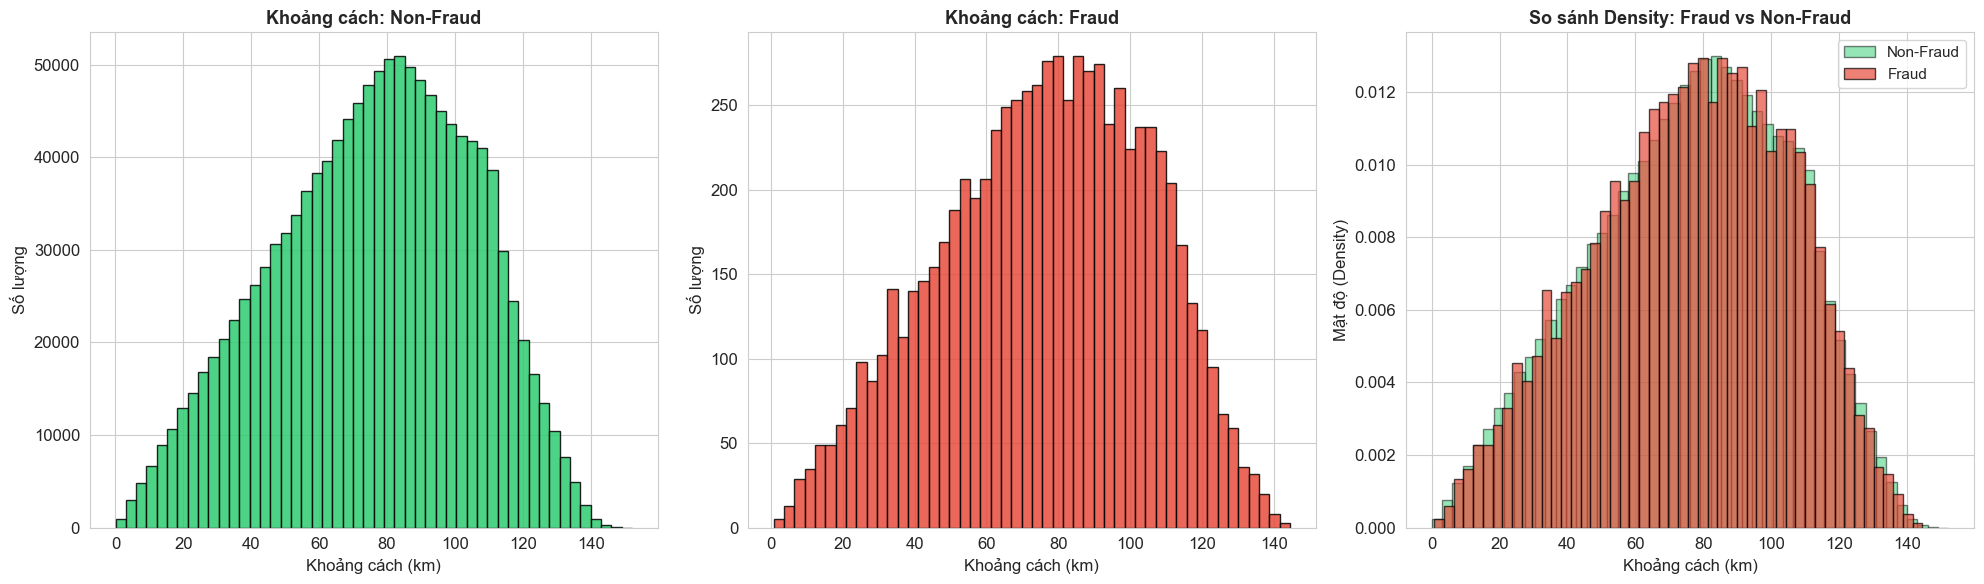

In [34]:
dist_pd = train_with_dist.select('distance_km', 'is_fraud').toPandas()
dist_nonfraud = dist_pd[dist_pd['is_fraud'] == 0]['distance_km']
dist_fraud = dist_pd[dist_pd['is_fraud'] == 1]['distance_km']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(dist_nonfraud, bins=50, color='#2ecc71', edgecolor='black', alpha=0.85)
axes[0].set_xlabel('Khoảng cách (km)', fontsize=12)
axes[0].set_ylabel('Số lượng', fontsize=12)
axes[0].set_title('Khoảng cách: Non-Fraud', fontsize=13, fontweight='bold')

axes[1].hist(dist_fraud, bins=50, color='#e74c3c', edgecolor='black', alpha=0.85)
axes[1].set_xlabel('Khoảng cách (km)', fontsize=12)
axes[1].set_ylabel('Số lượng', fontsize=12)
axes[1].set_title('Khoảng cách: Fraud', fontsize=13, fontweight='bold')

axes[2].hist(dist_nonfraud, bins=50, alpha=0.5, label='Non-Fraud', color='#2ecc71', edgecolor='black', density=True)
axes[2].hist(dist_fraud, bins=50, alpha=0.7, label='Fraud', color='#e74c3c', edgecolor='black', density=True)
axes[2].set_xlabel('Khoảng cách (km)', fontsize=12)
axes[2].set_ylabel('Mật độ (Density)', fontsize=12)
axes[2].set_title('So sánh Density: Fraud vs Non-Fraud', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Khoảng cách trung bình và median giữa fraud vs non-fraud **gần như tương đương** (avg ~76 km, median ~78 km) — sự khác biệt không có ý nghĩa thống kê rõ ràng.
- Phân bố khoảng cách của hai nhóm cũng khá giống nhau qua biểu đồ density.
- `distance_km` vẫn sẽ được tạo trong Feature Engineering để model tự đánh giá, nhưng **không nên kỳ vọng đây là feature phân biệt mạnh**.

---
## So sánh tập huấn luyện và tập kiểm tra

### Phân bố nhãn (Target Variable)

In [35]:
print("=" * 60)
print("PHÂN BỐ NHÃN — TẬP TRAIN")
print("=" * 60)

train_label = spark.sql("""
    SELECT 
        is_fraud,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM train), 4) as percentage
    FROM train
    GROUP BY is_fraud
    ORDER BY is_fraud
""")
train_label.show()

print("=" * 60)
print("PHÂN BỐ NHÃN — TẬP TEST")
print("=" * 60)

test_label = spark.sql("""
    SELECT 
        is_fraud,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM test), 4) as percentage
    FROM test
    GROUP BY is_fraud
    ORDER BY is_fraud
""")
test_label.show()

PHÂN BỐ NHÃN — TẬP TRAIN
+--------+-------+----------+
|is_fraud|  count|percentage|
+--------+-------+----------+
|       0|1289169|   99.4211|
|       1|   7506|    0.5789|
+--------+-------+----------+

PHÂN BỐ NHÃN — TẬP TEST
+--------+------+----------+
|is_fraud| count|percentage|
+--------+------+----------+
|       0|553574|   99.6140|
|       1|  2145|    0.3860|
+--------+------+----------+



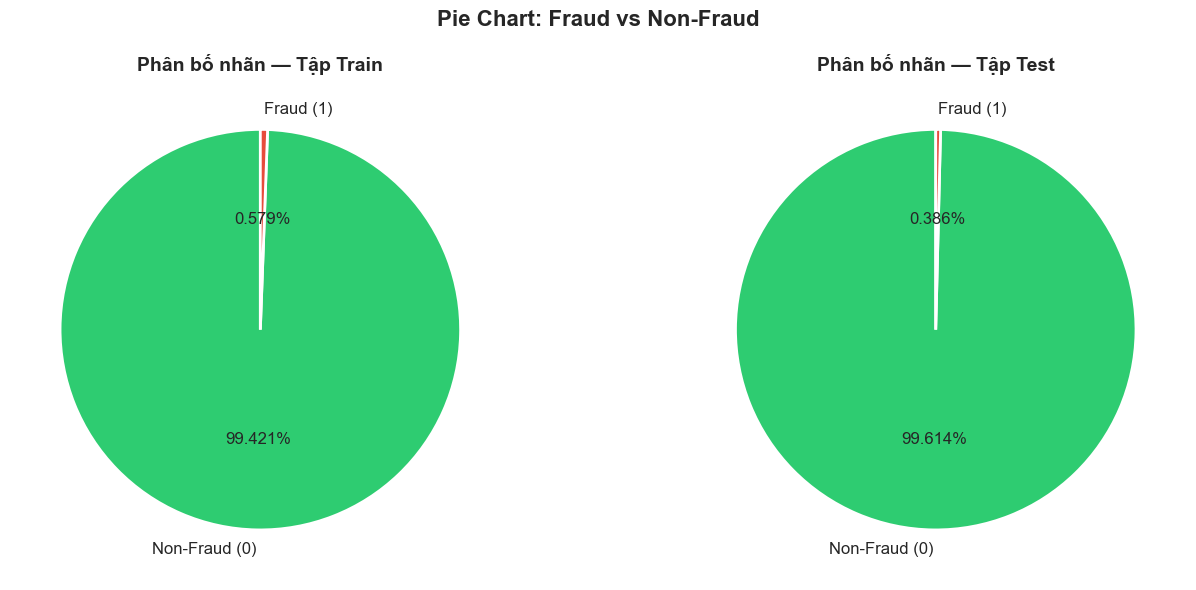

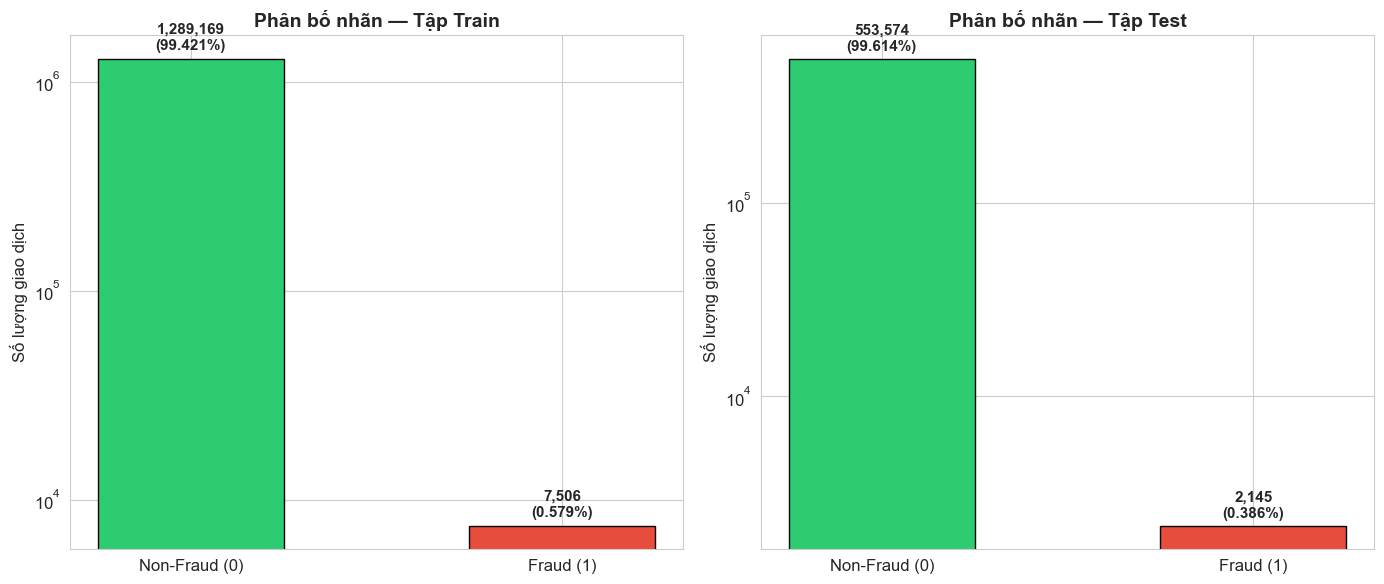

In [36]:
train_label_pd = train_label.toPandas()
test_label_pd = test_label.toPandas()
labels = ['Non-Fraud (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(train_label_pd['count'], labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90, pctdistance=0.55,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[0].set_title('Phân bố nhãn — Tập Train', fontsize=14, fontweight='bold')

axes[1].pie(test_label_pd['count'], labels=labels, autopct='%1.3f%%',
            colors=colors, startangle=90, pctdistance=0.55,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Phân bố nhãn — Tập Test', fontsize=14, fontweight='bold')

plt.suptitle('Pie Chart: Fraud vs Non-Fraud', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars = axes[0].bar(labels, train_label_pd['count'], color=colors, edgecolor='black', width=0.5)
axes[0].set_ylabel('Số lượng giao dịch', fontsize=12)
axes[0].set_title('Phân bố nhãn — Tập Train', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
for bar, val, pct in zip(bars, train_label_pd['count'], train_label_pd['percentage']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:,}\n({pct:.3f}%)', ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(labels, test_label_pd['count'], color=colors, edgecolor='black', width=0.5)
axes[1].set_ylabel('Số lượng giao dịch', fontsize=12)
axes[1].set_title('Phân bố nhãn — Tập Test', fontsize=14, fontweight='bold')
axes[1].set_yscale('log')
for bar, val, pct in zip(bars2, test_label_pd['count'], test_label_pd['percentage']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{val:,}\n({pct:.3f}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
- Dataset **cực kỳ mất cân bằng** — fraud chỉ chiếm ~0.58%, non-fraud ~99.42%.
- Đây là đặc trưng phổ biến trong bài toán fraud detection thực tế.
- Hệ quả: cần xử lý imbalanced data khi train model (class weight, undersampling, SMOTE...).
- **Metric đánh giá**: ưu tiên Precision, Recall, F1, AUC-PR thay vì Accuracy.

In [37]:
print("=" * 60)
print("SO SÁNH PHÂN BỐ AMOUNT: TRAIN vs TEST")
print("=" * 60)

print("--- TRAIN ---")
spark.sql("""
    SELECT 
        ROUND(AVG(amt), 2) as mean_amt,
        ROUND(STDDEV(amt), 2) as std_amt,
        ROUND(MIN(amt), 2) as min_amt,
        ROUND(MAX(amt), 2) as max_amt,
        ROUND(PERCENTILE_APPROX(amt, 0.5), 2) as median_amt
    FROM train
""").show(truncate=False)

print("--- TEST ---")
spark.sql("""
    SELECT 
        ROUND(AVG(amt), 2) as mean_amt,
        ROUND(STDDEV(amt), 2) as std_amt,
        ROUND(MIN(amt), 2) as min_amt,
        ROUND(MAX(amt), 2) as max_amt,
        ROUND(PERCENTILE_APPROX(amt, 0.5), 2) as median_amt
    FROM test
""").show(truncate=False)

SO SÁNH PHÂN BỐ AMOUNT: TRAIN vs TEST
--- TRAIN ---
+--------+-------+-------+-------+----------+
|mean_amt|std_amt|min_amt|max_amt|median_amt|
+--------+-------+-------+-------+----------+
|70.35   |160.32 |1.0    |28948.9|47.51     |
+--------+-------+-------+-------+----------+

--- TEST ---
+--------+-------+-------+--------+----------+
|mean_amt|std_amt|min_amt|max_amt |median_amt|
+--------+-------+-------+--------+----------+
|69.39   |156.75 |1.0    |22768.11|47.29     |
+--------+-------+-------+--------+----------+



In [38]:
print("=" * 60)
print("SO SÁNH FRAUD RATIO: TRAIN vs TEST")
print("=" * 60)

print("--- TRAIN ---")
spark.sql("""
    SELECT 
        is_fraud,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM train), 4) as pct
    FROM train GROUP BY is_fraud ORDER BY is_fraud
""").show()

print("--- TEST ---")
spark.sql("""
    SELECT 
        is_fraud,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM test), 4) as pct
    FROM test GROUP BY is_fraud ORDER BY is_fraud
""").show()

SO SÁNH FRAUD RATIO: TRAIN vs TEST
--- TRAIN ---
+--------+-------+-------+
|is_fraud|  count|    pct|
+--------+-------+-------+
|       0|1289169|99.4211|
|       1|   7506| 0.5789|
+--------+-------+-------+

--- TEST ---
+--------+------+-------+
|is_fraud| count|    pct|
+--------+------+-------+
|       0|553574|99.6140|
|       1|  2145| 0.3860|
+--------+------+-------+



In [39]:
print("=" * 60)
print("SO SÁNH PHÂN BỐ CATEGORY: TRAIN vs TEST")
print("=" * 60)

cat_train = spark.sql("""
    SELECT category, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM train), 2) as pct_train
    FROM train GROUP BY category ORDER BY category
""").toPandas()

cat_test = spark.sql("""
    SELECT category, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM test), 2) as pct_test
    FROM test GROUP BY category ORDER BY category
""").toPandas()

cat_compare = cat_train.merge(cat_test, on='category')
cat_compare['diff'] = abs(cat_compare['pct_train'] - cat_compare['pct_test'])
print(cat_compare.to_string(index=False))

SO SÁNH PHÂN BỐ CATEGORY: TRAIN vs TEST
      category pct_train pct_test diff
 entertainment      7.25     7.22 0.03
   food_dining      7.05     7.07 0.02
 gas_transport     10.15    10.14 0.01
   grocery_net      3.51     3.50 0.01
   grocery_pos      9.54     9.46 0.08
health_fitness      6.62     6.60 0.02
          home      9.49     9.42 0.07
     kids_pets      8.72     8.76 0.04
      misc_net      4.88     4.92 0.04
      misc_pos      6.14     6.22 0.08
 personal_care      7.00     7.08 0.08
  shopping_net      7.52     7.52 0.00
  shopping_pos      9.00     8.96 0.04
        travel      3.12     3.14 0.02


In [40]:
print("=" * 60)
print("SO SÁNH PHÂN BỐ GENDER: TRAIN vs TEST")
print("=" * 60)

gender_train = spark.sql("""
    SELECT gender, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM train), 2) as pct_train
    FROM train GROUP BY gender ORDER BY gender
""").toPandas()

gender_test = spark.sql("""
    SELECT gender, ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM test), 2) as pct_test
    FROM test GROUP BY gender ORDER BY gender
""").toPandas()

gender_compare = gender_train.merge(gender_test, on='gender')
gender_compare['diff'] = abs(gender_compare['pct_train'] - gender_compare['pct_test'])
print(gender_compare.to_string(index=False))

SO SÁNH PHÂN BỐ GENDER: TRAIN vs TEST
gender pct_train pct_test diff
     F     54.74    54.86 0.12
     M     45.26    45.14 0.12


In [41]:

print("=" * 60)
print("SO SÁNH PHÂN BỐ AGE: TRAIN vs TEST")
print("=" * 60)

age_train = spark.sql("""
    SELECT 
        CASE 
            WHEN age < 20 THEN '< 20'
            WHEN age BETWEEN 20 AND 29 THEN '20-29'
            WHEN age BETWEEN 30 AND 39 THEN '30-39'
            WHEN age BETWEEN 40 AND 49 THEN '40-49'
            WHEN age BETWEEN 50 AND 59 THEN '50-59'
            WHEN age BETWEEN 60 AND 69 THEN '60-69'
            WHEN age BETWEEN 70 AND 79 THEN '70-79'
            WHEN age >= 80 THEN '80+'
        END as age_group,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct_train
    FROM (
        SELECT *, FLOOR(DATEDIFF(trans_date_trans_time, dob) / 365.25) as age
        FROM train
        WHERE dob IS NOT NULL AND trans_date_trans_time IS NOT NULL
    )
    WHERE age IS NOT NULL AND age >= 0 AND age <= 120
    GROUP BY age_group
    ORDER BY age_group
""").toPandas()

age_test = spark.sql("""
    SELECT 
        CASE 
            WHEN age < 20 THEN '< 20'
            WHEN age BETWEEN 20 AND 29 THEN '20-29'
            WHEN age BETWEEN 30 AND 39 THEN '30-39'
            WHEN age BETWEEN 40 AND 49 THEN '40-49'
            WHEN age BETWEEN 50 AND 59 THEN '50-59'
            WHEN age BETWEEN 60 AND 69 THEN '60-69'
            WHEN age BETWEEN 70 AND 79 THEN '70-79'
            WHEN age >= 80 THEN '80+'
        END as age_group,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as pct_test
    FROM (
        SELECT *, FLOOR(DATEDIFF(trans_date_trans_time, dob) / 365.25) as age
        FROM test
        WHERE dob IS NOT NULL AND trans_date_trans_time IS NOT NULL
    )
    WHERE age IS NOT NULL AND age >= 0 AND age <= 120
    GROUP BY age_group
    ORDER BY age_group
""").toPandas()

age_compare = age_train.merge(age_test, on='age_group')
age_compare['diff'] = abs(age_compare['pct_train'] - age_compare['pct_test'])
print(age_compare.to_string(index=False))

SO SÁNH PHÂN BỐ AGE: TRAIN vs TEST


age_group pct_train pct_test diff
    20-29     16.14    15.29 0.85
    30-39     22.46    22.96 0.50
    40-49     23.47    23.24 0.23
    50-59     14.26    14.73 0.47
    60-69     10.53    10.94 0.41
    70-79      5.62     5.93 0.31
      80+      4.83     5.27 0.44
     < 20      2.69     1.63 1.06


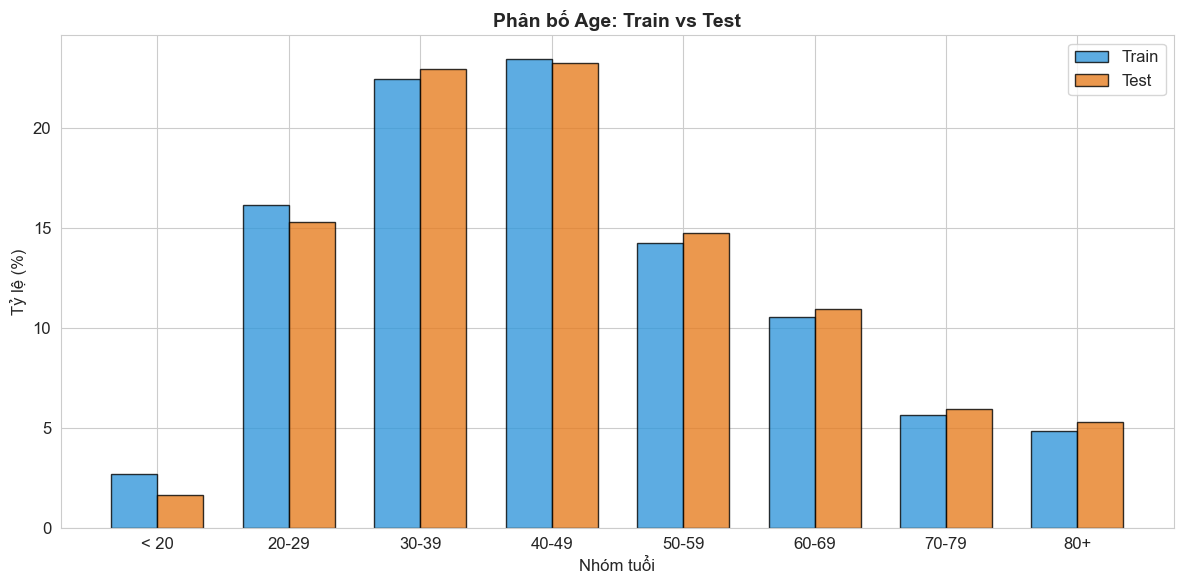

In [42]:
age_order = ['< 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
age_compare['age_group'] = pd.Categorical(age_compare['age_group'], categories=age_order, ordered=True)
age_compare = age_compare.sort_values('age_group')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(age_compare))
bar_width = 0.35

ax.bar(x - bar_width/2, age_compare['pct_train'], bar_width,
       label='Train', color='#3498db', edgecolor='black', alpha=0.8)
ax.bar(x + bar_width/2, age_compare['pct_test'], bar_width,
       label='Test', color='#e67e22', edgecolor='black', alpha=0.8)

ax.set_xlabel('Nhóm tuổi', fontsize=12)
ax.set_ylabel('Tỷ lệ (%)', fontsize=12)
ax.set_title('Phân bố Age: Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(age_compare['age_group'])
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

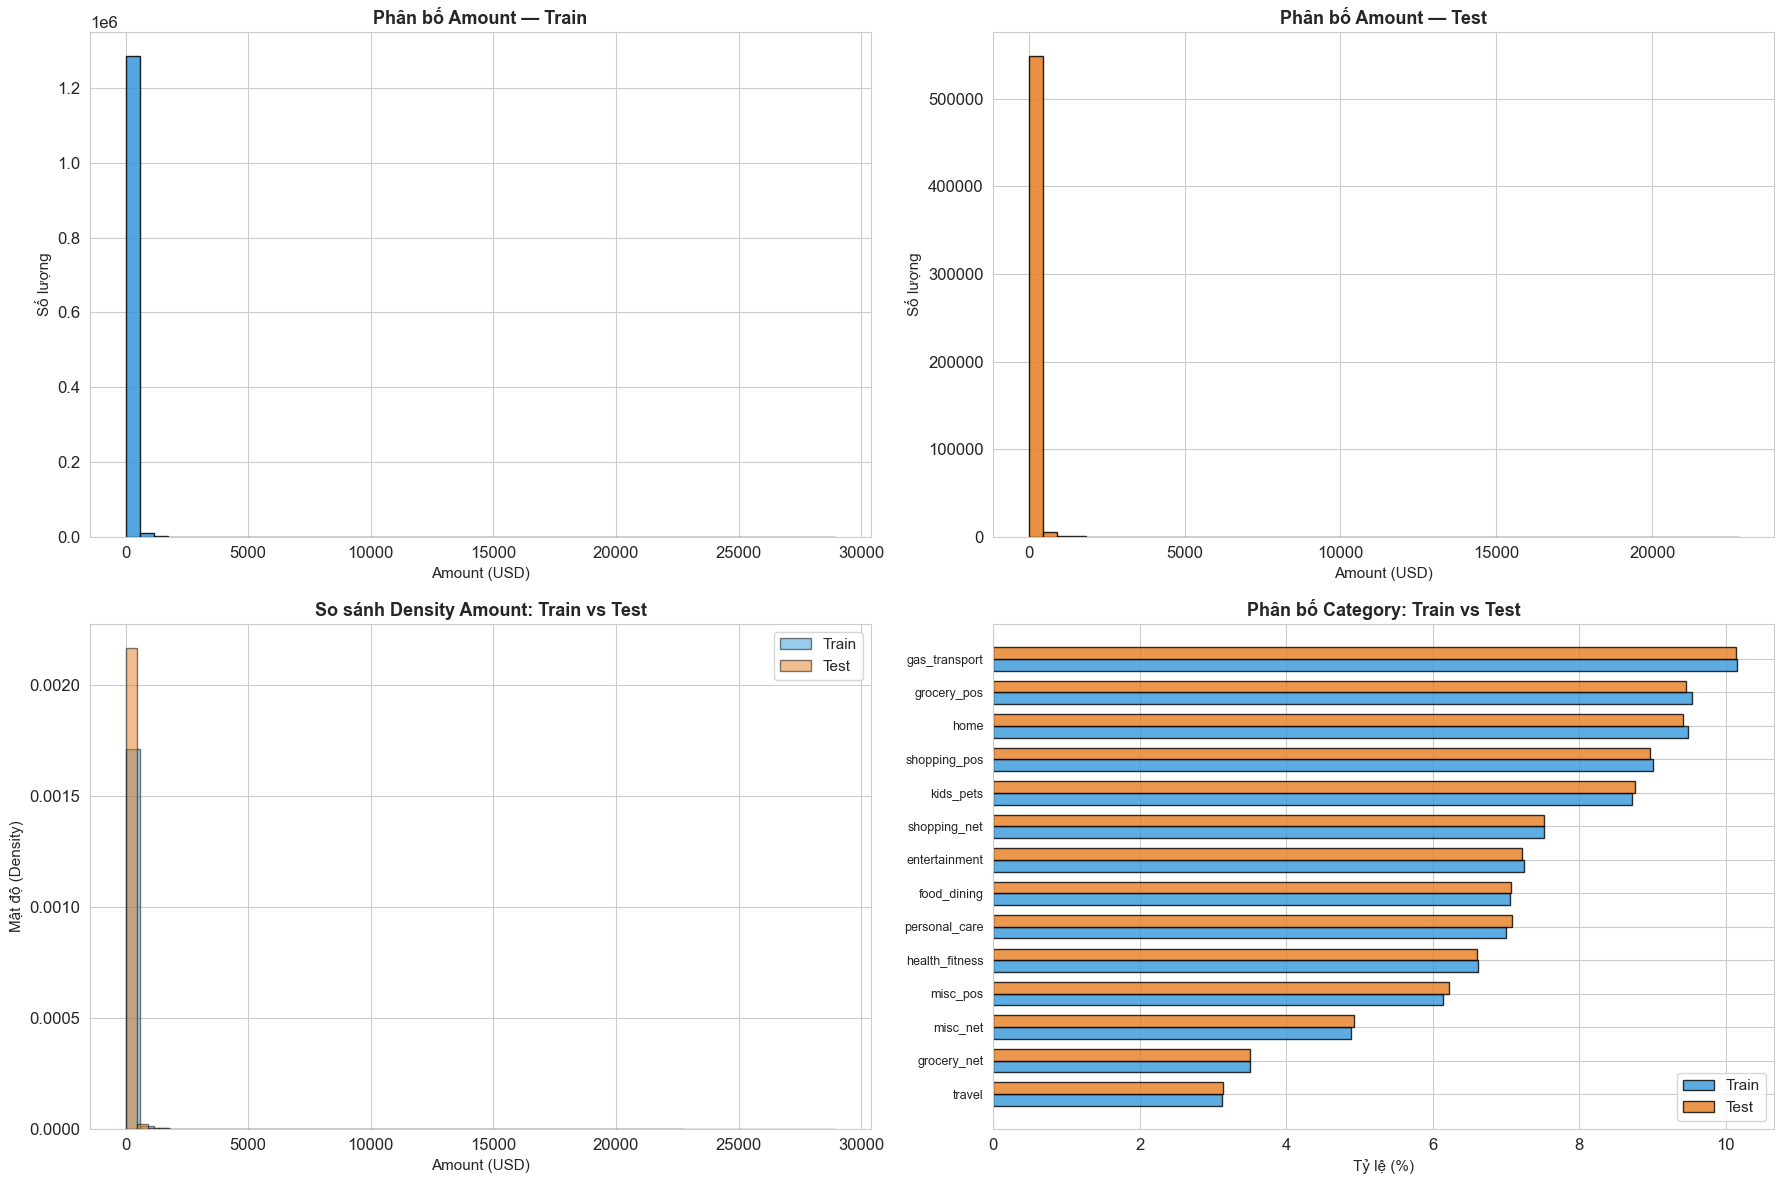

In [43]:
amt_train_pd = train_df.select('amt').toPandas()['amt']
amt_test_pd = test_df.select('amt').toPandas()['amt']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].hist(amt_train_pd, bins=50, color='#3498db', edgecolor='black', alpha=0.85)
axes[0, 0].set_xlabel('Amount (USD)', fontsize=11)
axes[0, 0].set_ylabel('Số lượng', fontsize=11)
axes[0, 0].set_title('Phân bố Amount — Train', fontsize=13, fontweight='bold')

axes[0, 1].hist(amt_test_pd, bins=50, color='#e67e22', edgecolor='black', alpha=0.85)
axes[0, 1].set_xlabel('Amount (USD)', fontsize=11)
axes[0, 1].set_ylabel('Số lượng', fontsize=11)
axes[0, 1].set_title('Phân bố Amount — Test', fontsize=13, fontweight='bold')

axes[1, 0].hist(amt_train_pd, bins=50, alpha=0.5, label='Train', color='#3498db', edgecolor='black', density=True)
axes[1, 0].hist(amt_test_pd, bins=50, alpha=0.5, label='Test', color='#e67e22', edgecolor='black', density=True)
axes[1, 0].set_xlabel('Amount (USD)', fontsize=11)
axes[1, 0].set_ylabel('Mật độ (Density)', fontsize=11)
axes[1, 0].set_title('So sánh Density Amount: Train vs Test', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=11)

cat_compare_sorted = cat_compare.sort_values('pct_train', ascending=True)
y_pos = np.arange(len(cat_compare_sorted))
bar_height = 0.35
axes[1, 1].barh(y_pos - bar_height/2, cat_compare_sorted['pct_train'].values, bar_height,
                 label='Train', color='#3498db', edgecolor='black', alpha=0.8)
axes[1, 1].barh(y_pos + bar_height/2, cat_compare_sorted['pct_test'].values, bar_height,
                 label='Test', color='#e67e22', edgecolor='black', alpha=0.8)
axes[1, 1].set_yticks(y_pos)
axes[1, 1].set_yticklabels(cat_compare_sorted['category'].values, fontsize=9)
axes[1, 1].set_xlabel('Tỷ lệ (%)', fontsize=11)
axes[1, 1].set_title('Phân bố Category: Train vs Test', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=11)

plt.tight_layout()
plt.show()

**Nhận xét:**
- Phân bố feature (amount, category, gender, age) giữa train và test **khá ổn định**.
- Tuy nhiên, có dấu hiệu **label shift nhẹ**: fraud ratio train (~0.58%) vs test (~0.39%) — chênh lệch đáng kể theo tỷ lệ tương đối (~33%). Điều này có thể do dataset được split theo thời gian.
- Kết luận: tập test vẫn đáng tin cậy để đánh giá model, nhưng cần lưu ý label shift khi phân tích kết quả.

In [44]:
spark.stop()
